# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


Matplotlib is building the font cache; this may take a moment.


In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [15]:
# Your code here
# a
print(penguins.shape)
# b
print(penguins.columns)
print(penguins.dtypes)
# c
#penguins.info

# d
penguins.groupby(penguins['species']).count()

(344, 8)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
species,,,,,,,
Adelie,152,151,151,151,151,146,152
Chinstrap,68,68,68,68,68,68,68
Gentoo,124,123,123,123,123,119,124


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [20]:
# Your code here
penguins_clean = penguins.dropna().copy()
penguins_clean.shape

(333, 8)

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [31]:
# a
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [32]:
# b
penguins_clean.groupby(by = 'species').mean(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
species,,,,,
Adelie,38.824,18.347,190.103,3706.164,2008.055
Chinstrap,48.834,18.421,195.824,3733.088,2007.971
Gentoo,47.568,14.997,217.235,5092.437,2008.067


In [33]:
penguins_clean.groupby(by = 'species').std(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
species,,,,,
Adelie,2.663,1.219,6.522,458.620,0.812
Chinstrap,3.339,1.135,7.132,384.335,0.863
Gentoo,3.106,0.986,6.585,501.476,0.789


### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [40]:
# a
species_sex_means = penguins_clean.drop(columns = 'year').groupby(['species', 'sex']).mean(numeric_only = True)
species_sex_means

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    female          37.258         17.622            187.795   
          male            40.390         19.073            192.411   
Chinstrap female          46.574         17.588            191.735   
          male            51.094         19.253            199.912   
Gentoo    female          45.564         14.238            212.707   
          male            49.474         15.718            221.541   

                  body_mass_g  
species   sex                  
Adelie    female     3368.836  
          male       4043.493  
Chinstrap female     3527.206  
          male       3938.971  
Gentoo    female     4679.741  
          male       5484.836

In [39]:
penguins_clean.drop(columns = 'year').groupby(['species', 'sex']).count()

island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                                
Adelie    female      73              73             73                 73   
          male        73              73             73                 73   
Chinstrap female      34              34             34                 34   
          male        34              34             34                 34   
Gentoo    female      58              58             58                 58   
          male        61              61             61                 61   

                  body_mass_g  
species   sex                  
Adelie    female           73  
          male             73  
Chinstrap female           34  
          male             34  
Gentoo    female           58  
          male             61

In [41]:
# b
species_sex_means.loc[species_sex_means.body_mass_g == max(species_sex_means.body_mass_g)]

,,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,sex,,,,
Gentoo,male,49.474,15.718,221.541,5484.836


### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [47]:
# a
penguins_clean.corr(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000,-0.229,0.653,0.589,0.033
bill_depth_mm,-0.229,1.000,-0.578,-0.472,-0.048
flipper_length_mm,0.653,-0.578,1.000,0.873,0.151
body_mass_g,0.589,-0.472,0.873,1.000,0.022
year,0.033,-0.048,0.151,0.022,1.000


In [48]:
# b
penguins_clean.groupby(by = 'species').corr(numeric_only = True)

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
          year                        0.011         -0.235              0.328   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
          year                        0.042         -0.059              0.346   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   
          year                        0.205          0.243              0.201   

                             body_mass_g   year  
species                                          
Adelie    bill_length_mm           0.544  0.011  
          bill_depth_mm            0.580 -0.235  
          flipper_length_mm        0.465  0.328  
          body_mass_g              1.000 -0.046  
          year                    -0.046  1.000  
Chinstrap bill_length_mm           0.514  0.042  
          bill_depth_mm            0.604 -0.059  
          flipper_length_mm        0.642  0.346  
          body_mass_g              1.000  0.037  
          year                     0.037  1.000  
Gentoo    bill_length_mm           0.667  0.205  
          bill_depth_mm            0.723  0.243  
          flipper_length_mm        0.711  0.201  
          body_mass_g              1.000  0.052  
          year                     0.052  1.000

In [ ]:
# c


## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


TypeError: cannot unpack non-iterable Axes object

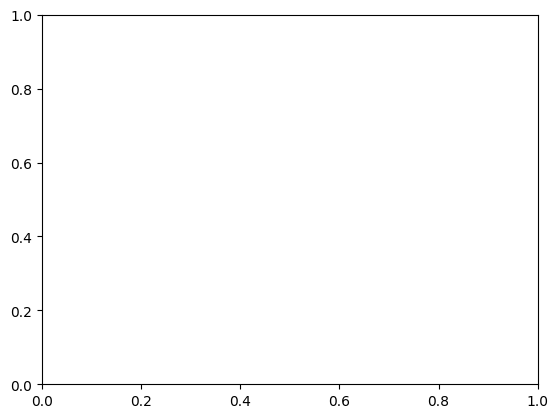

In [50]:
fig, ax = plt.subplot()
ax.hist2d(penguins_clean['body_mass_g'])

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

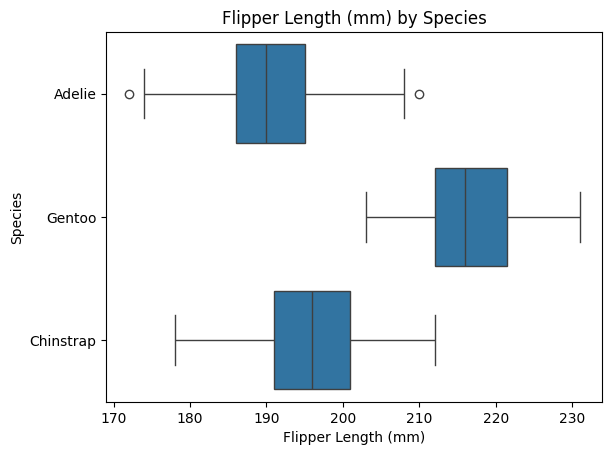

In [63]:
fig, ax = plt.subplots()
sns.boxplot(x="flipper_length_mm", y="species", data=penguins_clean, ax=ax)
ax.set_title("Flipper Length (mm) by Species")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Species")
plt.show()

The Gentoo species has the highest median flipper length.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

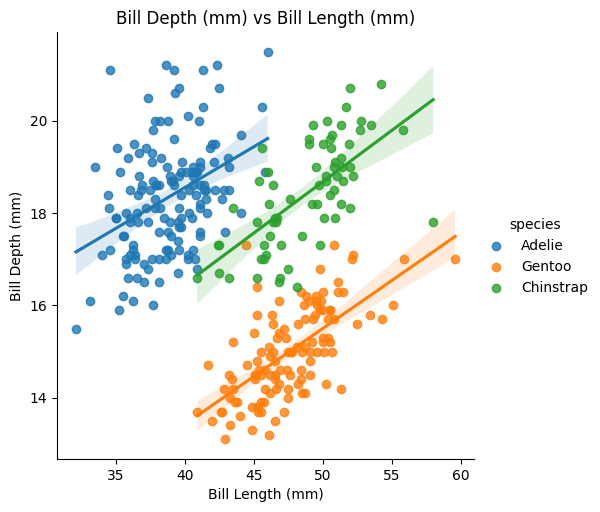

In [72]:
scatter = sns.lmplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm', hue='species')
scatter.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
plt.title("Bill Depth (mm) vs Bill Length (mm)")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 